# import thư viện

In [42]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# thêm dữ liệu

In [43]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1


In [44]:
# Cai dat url cua dataset
import os
DATA_DIR = os.path.join(path, "asl_alphabet_train","asl_alphabet_train")

# chuẩn hóa dữ liệu

In [45]:
# Khai bao tham so can thiet
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 29

In [46]:
# tang cuong du lieu
train_datagen = ImageDataGenerator(
    rescale = 1.255, # chuyen mau tu 0 den 255 ve 0 den 1
    validation_split = 0.2, # 20% test + 80% train
    rotation_range = 20, # xoay anh trong khoang 20 do
    zoom_range = 0.2, # phong to anh trong khoang 20%
    width_shift_range = 0.2, # dich chuyen anh theo chieu ngang trong khoang 20%
    height_shift_range = 0.2, # dich chuyen anh theo chieu doc trong khoang 20%
    horizontal_flip = False, # khong lat nguoc anh
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=0.2)

In [47]:
# load train data
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
)

Found 69600 images belonging to 29 classes.


In [48]:
# load validation data
validation_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
)

Found 17400 images belonging to 29 classes.


## Chú thích về validation:
- Tập `train` có mục đích là học
- Tập `validation` theo dõi khi train: *đem model đang học đi test với tập val -> không cập nhật weight mà chi đo `val_loss`, `val_accuracy`*
- Tập `test` đánh giá cuối cùng (người dùng tự test)

In [49]:
# load test data
TEST_DATA_DIR = os.path.join(path, "asl_alphabet_test","asl_alphabet_test") 
test_generator = test_datagen.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False, #tron du lieu test (khong can thiet)
)

Found 0 images belonging to 0 classes.


Số lớp: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


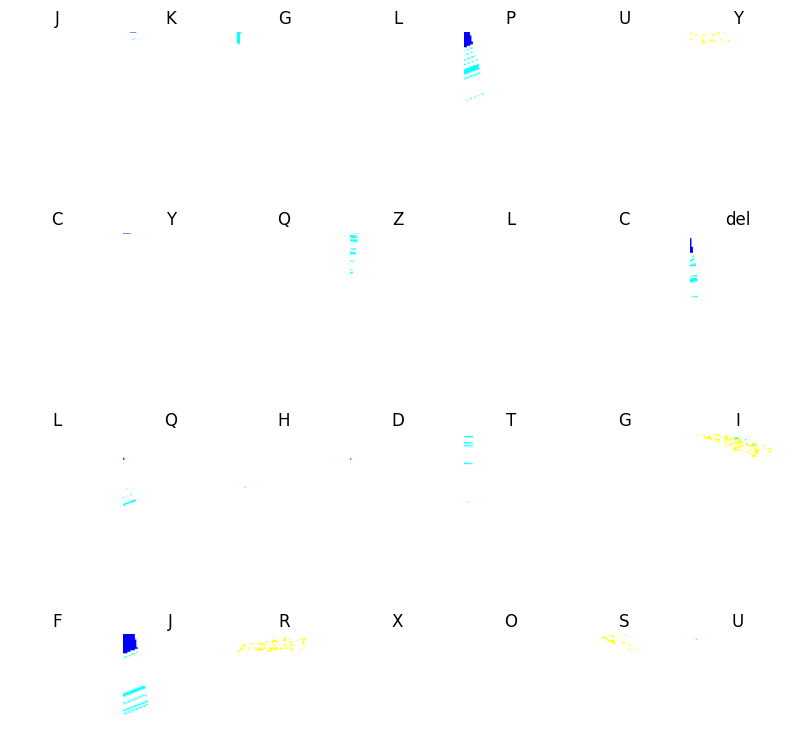

In [50]:
class_names = list(train_generator.class_indices.keys())
print("Số lớp:", len(class_names))
print(class_names)

import matplotlib.pyplot as plt
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(28):
    plt.subplot(4,7,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.show()

# khai báo mô hình

In [51]:
# CNN
model = Sequential(
    [
        Conv2D(
            32,
            (3,3),
            activation="relu",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)   #3: 3 direction: rgb
        ),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation="relu"),

        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation="relu"),

        MaxPooling2D(2,2),
        
        Flatten(),

        Dense(256, activation="relu"),

        Dropout(0.5),   #ngan chan overfitting
        Dense(NUM_CLASSES, activation="softmax"),
])

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,605 (4.89 MB)

 Trainable params: 1,280,605 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

# train mô hình

In [53]:
history = model.fit(
    train_generator, validation_data=validation_generator, epochs=EPOCHS
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 480s 220ms/step - accuracy: 0.2780 - loss: 2.6228 - val_accuracy: 0.4883 - val_loss: 1.6390
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 415s 191ms/step - accuracy: 0.6747 - loss: 1.0191 - val_accuracy: 0.6524 - val_loss: 1.1784
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 280s 129ms/step - accuracy: 0.7700 - loss: 0.7194 - val_accuracy: 0.6908 - val_loss: 1.0612
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 294s 135ms/step - accuracy: 0.8108 - loss: 0.6077 - val_accuracy: 0.7337 - val_loss: 0.8907
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 351s 161ms/step - accuracy: 0.8339 - loss: 0.5475 - val_accuracy: 0.6889 - val_loss: 1.0929
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 283s 130ms/step - accuracy: 0.8469 - loss: 0.5145 - val_accuracy: 0.7374 - val_loss: 0.9165
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 296s 136ms/step - accuracy: 0.8525 - loss: 0.5025 - val_accuracy: 0.7478 - val_loss: 0.8859
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 383s 176ms/step - ac

In [54]:
# luu mo hinh
model.save("asl_model.h5")
print("Đã lưu mô hình")

Đã lưu mô hình


# đánh giá mô hình

In [55]:
# kieu phan lop -> loss va accuracy
loss, accuracy = model.evaluate(validation_generator)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

544/544 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - accuracy: 0.7695 - loss: 0.8933
Test loss: 0.8933
Test accuracy: 0.7695


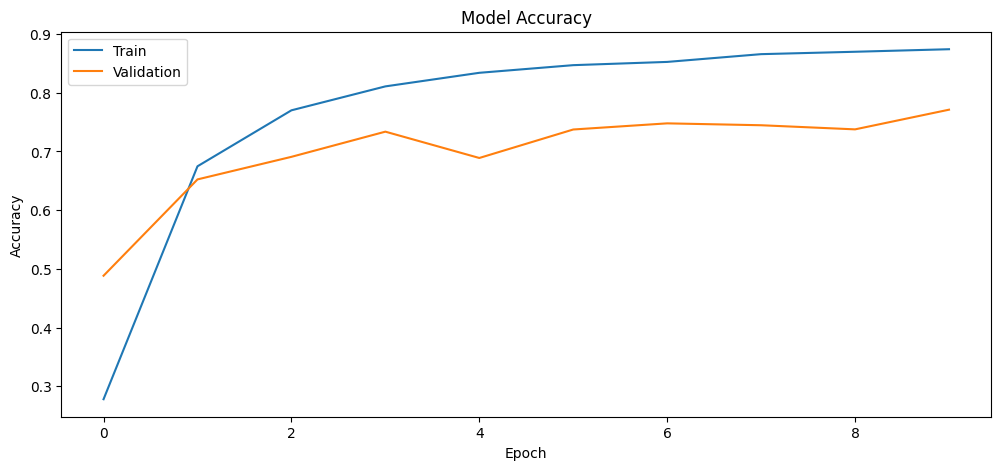

In [56]:
# bieu do accuracy
plt.figure(figsize=(12, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# test mô hình